In [1]:
#Getting libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

### SEM & Particle Size Metrology (Structure)

In [2]:
# Path to the SEM image file in the unzipped folder
image_path = "data/6623361_SEM_Pics_2022.165847/4a.tif"

In [3]:
# image in grayscale mode; 0 = black, 255 = white
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#image shape (height and width in pixels)
height, width = image_gray.shape
print(f"Image Resolution: {width} x {height} pixels", f"Data Type: {image_gray.dtype}", f"Pixel Intensity Range: Min = {image_gray.min()}, Max = {image_gray.max()}")

Image Resolution: 1024 x 768 pixels Data Type: uint8 Pixel Intensity Range: Min = 0, Max = 255


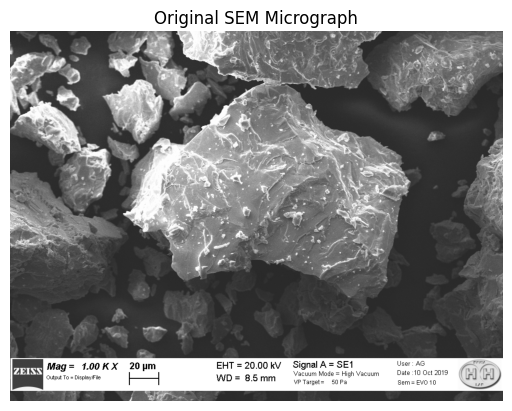

Calibration set: 1 pixel = 0.2 um | Image size: 1024x768 px


In [4]:
# Cell 2: Display original SEM micrograph with scale calibration
pixel_to_micron = 0.2  # Calibration: 1 pixel = 0.2 micrometers
plt.imshow(image_gray, cmap='gray')
plt.title("Original SEM Micrograph")
plt.axis('off')
plt.show()

print(f"Calibration set: 1 pixel = {pixel_to_micron} um | Image size: {image_gray.shape[1]}x{image_gray.shape[0]} px")

In [5]:
# image in color mode (1 = default color, loads as BGR)
image_color = cv2.imread('data/6623361_SEM_Pics_2022.165847/4a.tif', 1) 
height, width, channels = image_color.shape
print("Image loaded successfully in COLOR mode!")
print(f"Image Resolution: {width} x {height} pixels")
print(f"Number of Channels: {channels} (BGR)")
print(f"Data Type: {image_color.dtype}")
print(f"Pixel Intensity Range: Min = {image_color.min()}, Max = {image_color.max()}")


Image loaded successfully in COLOR mode!
Image Resolution: 1024 x 768 pixels
Number of Channels: 3 (BGR)
Data Type: uint8
Pixel Intensity Range: Min = 0, Max = 255


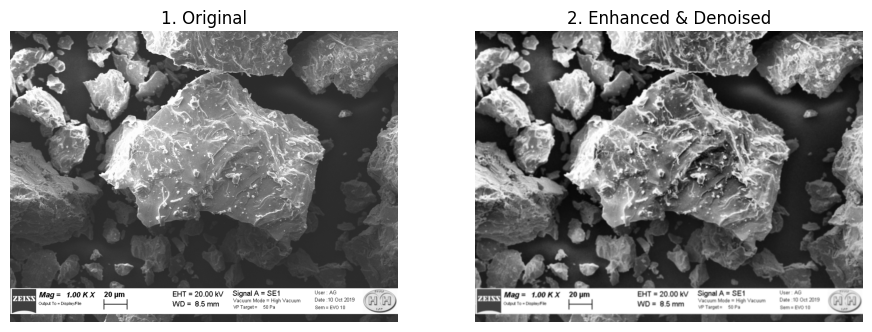

Pre-processing complete: Applied CLAHE contrast (clip=3.0) and 5x5 Gaussian blur.


In [6]:
# Contrast Enhancement (CLAHE) and Denoising (Gaussian Blur)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
img_enhanced = clahe.apply(image_gray)
img_smoothed = cv2.GaussianBlur(img_enhanced, (5, 5), 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))
ax1.imshow(image_gray, cmap='gray'); ax1.set_title("1. Original"); ax1.axis('off')
ax2.imshow(img_smoothed, cmap='gray'); ax2.set_title("2. Enhanced & Denoised"); ax2.axis('off')
plt.savefig('plots/enhanced and denoised.png')
plt.show()

print(f"Pre-processing complete: Applied CLAHE contrast (clip=3.0) and 5x5 Gaussian blur.")

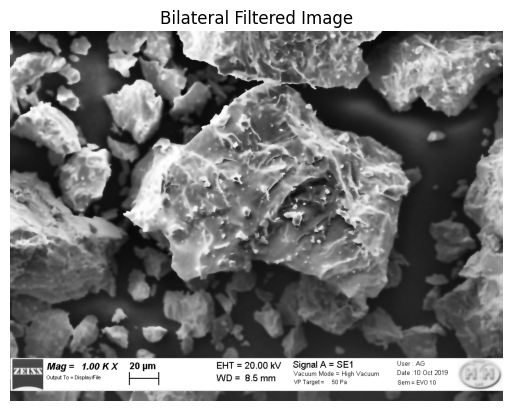

Bilateral Filter complete: Noise smoothed while keeping particle edges sharp (d=9).


In [7]:
# Cell 3b1: Bilateral Filter (Edge-Preserving Denoising)
import cv2, matplotlib.pyplot as plt

img_bilateral = cv2.bilateralFilter(img_enhanced, d=9, sigmaColor=75, sigmaSpace=75)

plt.imshow(img_bilateral, cmap='gray'); plt.title("Bilateral Filtered Image"); plt.axis('off'); plt.show()

print(f"Bilateral Filter complete: Noise smoothed while keeping particle edges sharp (d=9).")

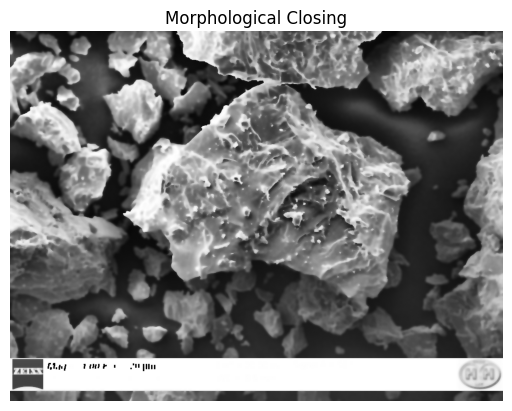

Morphological Closing complete: Filled small internal holes and surface cracks using 3x3 kernel.


In [8]:
# Cell 3b2: Morphological Closing (Fill Internal Grain Cracks & Holes)
import cv2, matplotlib.pyplot as plt

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
img_closed = cv2.morphologyEx(img_bilateral, cv2.MORPH_CLOSE, kernel)

plt.imshow(img_closed, cmap='gray'); plt.title("Morphological Closing"); plt.axis('off'); plt.show()

print(f"Morphological Closing complete: Filled small internal holes and surface cracks using 3x3 kernel.")

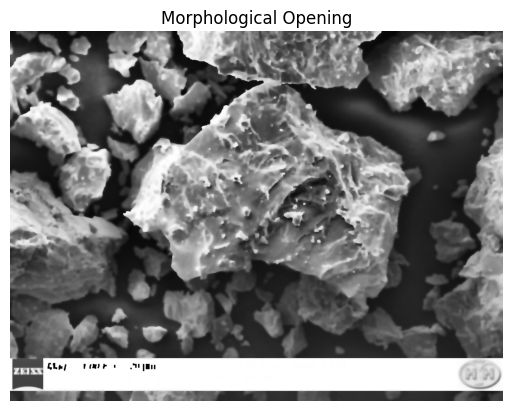

Morphological Opening complete: Removed isolated background noise specks using 3x3 kernel.


In [9]:
# Cell 3b3: Morphological Opening (Remove Background Noise Specks)
import cv2, matplotlib.pyplot as plt

img_opened = cv2.morphologyEx(img_closed, cv2.MORPH_OPEN, kernel)

plt.imshow(img_opened, cmap='gray'); plt.title("Morphological Opening"); plt.axis('off'); plt.show()

print(f"Morphological Opening complete: Removed isolated background noise specks using 3x3 kernel.")

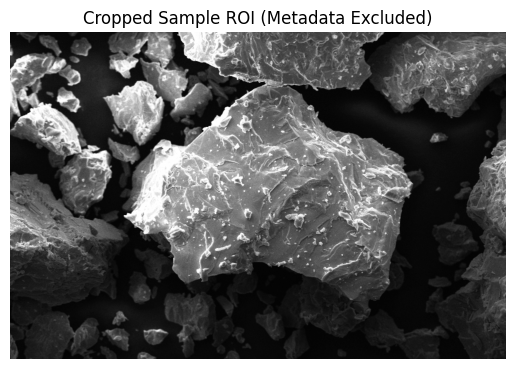

ROI Cropping complete: Sample area cropped to 1024x675 px (metadata excluded).


In [10]:
# Cell 3b3_crop: Crop Sample Region of Interest (ROI) to Exclude Metadata Banner
# Crop out the bottom ~10% (metadata banner region)
height = image_gray.shape[0]
roi_sample = image_gray[0:int(height * 0.88), :]  # Keep top 88% (powder sample only)

plt.imshow(roi_sample, cmap='gray'); plt.title("Cropped Sample ROI (Metadata Excluded)"); plt.axis('off'); plt.show()

print(f"ROI Cropping complete: Sample area cropped to {roi_sample.shape[1]}x{roi_sample.shape[0]} px (metadata excluded).")

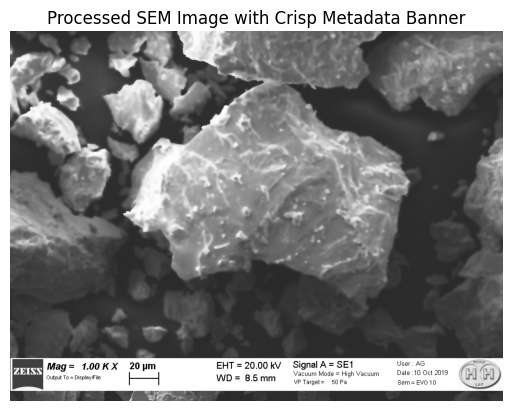

Combined Image ready: Sample area filtered, metadata banner preserved at bottom (1024x768 px).


In [11]:
# Cell 3b3_reattach: Process Sample Area while Preserving Crisp Metadata Banner
h = image_gray.shape[0]
sample_area = image_gray[0:int(h*0.88), :]
meta_banner = image_gray[int(h*0.88):, :]  # Original metadata banner

# Filter ONLY the sample area
sample_clean = cv2.morphologyEx(cv2.bilateralFilter(sample_area, 9, 75, 75), cv2.MORPH_OPEN, kernel)

# Re-attach original crisp metadata banner back at the bottom
full_combined = np.vstack([sample_clean, meta_banner])
plt.imshow(full_combined, cmap='gray'); plt.title("Processed SEM Image with Crisp Metadata Banner"); plt.axis('off'); plt.show()
print(f"Combined Image ready: Sample area filtered, metadata banner preserved at bottom ({full_combined.shape[1]}x{full_combined.shape[0]} px).")

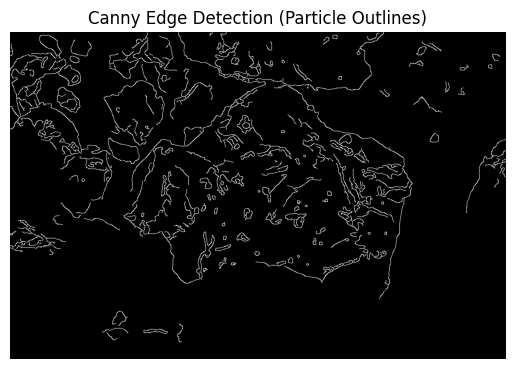

Canny Edge Detection complete: Particle boundary outlines extracted (T1=50, T2=150).


In [12]:
# Cell 3b4: Canny Edge Detection (Extract Particle Outlines)
import cv2, matplotlib.pyplot as plt

edges = cv2.Canny(sample_clean, threshold1=50, threshold2=150)

plt.imshow(edges, cmap='gray'); plt.title("Canny Edge Detection (Particle Outlines)"); plt.axis('off'); plt.show()

print(f"Canny Edge Detection complete: Particle boundary outlines extracted (T1=50, T2=150).")

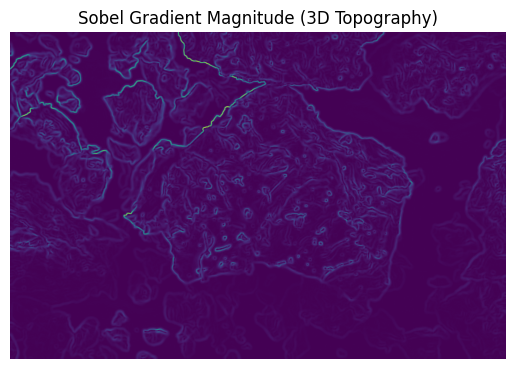

Sobel Gradient Filtering complete: Surface roughness and crack features highlighted.


In [13]:
# Cell 3b5: Sobel Gradient Filtering (Highlight 3D Surface Topography & Cracks)
import cv2, matplotlib.pyplot as plt

sobel_x = cv2.Sobel(sample_clean, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(sample_clean, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

plt.imshow(sobel_mag, cmap='viridis'); plt.title("Sobel Gradient Magnitude (3D Topography)"); plt.axis('off'); plt.show()

print(f"Sobel Gradient Filtering complete: Surface roughness and crack features highlighted.")

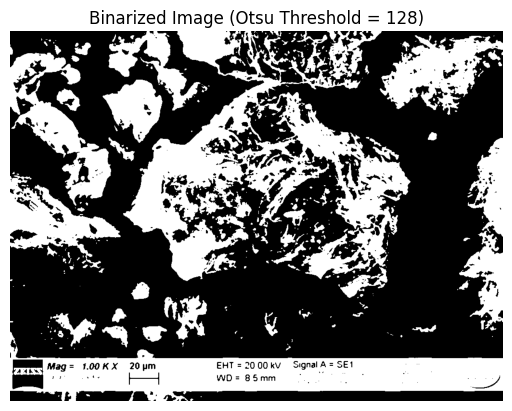

Otsu thresholding complete: Optimal threshold value = 128.


In [14]:
# Image Binarization; Otsu's Thresholding
thresh_val, binary_img = cv2.threshold(img_smoothed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(binary_img, cmap='gray')
plt.title(f"Binarized Image (Otsu Threshold = {thresh_val:.0f})")
plt.axis('off')
plt.show()

print(f"Otsu thresholding complete: Optimal threshold value = {thresh_val:.0f}.")

In [15]:
import numpy as np, matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

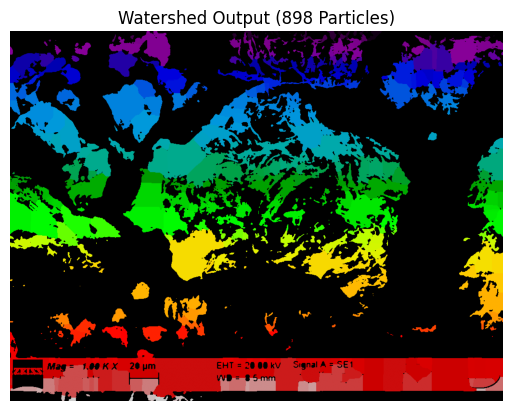

Watershed segmentation complete: Successfully identified 898 individual particles.


In [16]:
# Watershed Segmentation to Separate Touching Particles
distance = ndi.distance_transform_edt(binary_img)
coords = peak_local_max(distance, footprint=np.ones((15, 15)), labels=binary_img)
mask = np.zeros(distance.shape, dtype=bool); mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=binary_img)

plt.imshow(labels, cmap='nipy_spectral')
plt.title(f"Watershed Output ({len(np.unique(labels))-1} Particles)")
plt.axis('off')
plt.show()

print(f"Watershed segmentation complete: Successfully identified {len(np.unique(labels))-1} individual particles.")

In [17]:
# Particle Diameters and Size Metrics (D10, D50, D90)
data = []
for p in regionprops(labels):
    if p.area >= 20:  # Ignore tiny noise specks
        d_um = p.equivalent_diameter_area * pixel_to_micron
        data.append(d_um)

d10, d50, d90 = np.percentile(data, [10, 50, 90])

print(f"Total Particles: {len(data)} | D10 = {d10:.1f} um | D50 = {d50:.1f} um | D90 = {d90:.1f} um")

Total Particles: 738 | D10 = 1.3 um | D50 = 2.9 um | D90 = 6.6 um


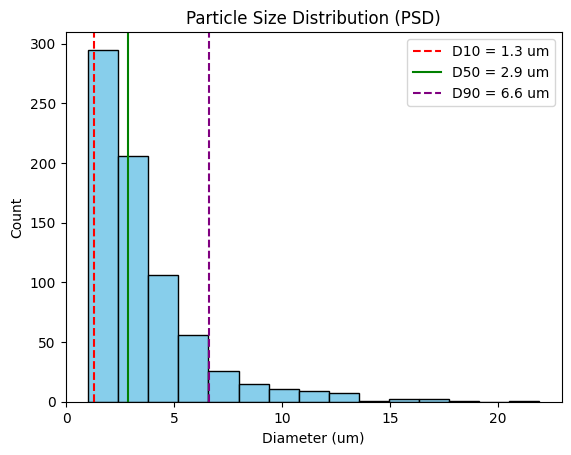

PSD Plot generated: Median particle size D50 = 2.9 um across 738 particles.


In [18]:
# Particle Size Distribution (PSD) Histogram
plt.hist(data, bins=15, color='skyblue', edgecolor='black')
plt.axvline(d10, color='red', ls='--', label=f'D10 = {d10:.1f} um')
plt.axvline(d50, color='green', ls='-', label=f'D50 = {d50:.1f} um')
plt.axvline(d90, color='purple', ls='--', label=f'D90 = {d90:.1f} um')
plt.title("Particle Size Distribution (PSD)"); plt.xlabel("Diameter (um)"); plt.ylabel("Count")
plt.legend(); plt.show()

print(f"PSD Plot generated: Median particle size D50 = {d50:.1f} um across {len(data)} particles.")

In [19]:
# Cell 7b: Measure Feret Diameter and Aspect Ratio
feret_dims, aspect_ratios = [], []
for p in regionprops(labels):
    if p.area >= 20:
        feret = p.major_axis_length * pixel_to_micron  # Max Feret diameter in um
        aspect = p.major_axis_length / (p.minor_axis_length + 1e-6)  # Aspect ratio
        feret_dims.append(feret)
        aspect_ratios.append(aspect)

print(f"Mean Max Feret Diameter = {np.mean(feret_dims):.1f} um | Mean Aspect Ratio = {np.mean(aspect_ratios):.2f}")

Mean Max Feret Diameter = 5.0 um | Mean Aspect Ratio = 1.86


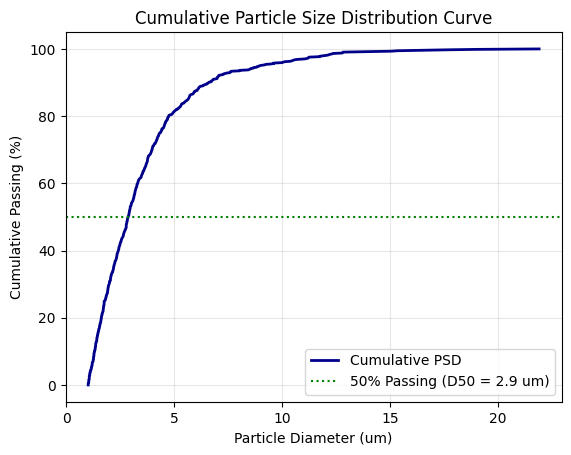

Cumulative curve plotted: 2.9 um at 50% passing mark across 738 particles.


In [20]:
# Cell 7c: Plot Cumulative Particle Size Distribution (S-Curve)
sorted_d = np.sort(data)
cumulative_pct = np.linspace(0, 100, len(sorted_d))

plt.plot(sorted_d, cumulative_pct, color='darkblue', lw=2, label='Cumulative PSD')
plt.axhline(50, color='green', ls=':', label=f'50% Passing (D50 = {d50:.1f} um)')
plt.title("Cumulative Particle Size Distribution Curve"); plt.xlabel("Particle Diameter (um)"); plt.ylabel("Cumulative Passing (%)")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

print(f"Cumulative curve plotted: {d50:.1f} um at 50% passing mark across {len(data)} particles.")

### EDX Elemental Mapping & Composition (bulk elemental map)

In [21]:
# 4 EDX Map Images (Ti, Fe, Mn, O)
p_ti = "data/6623361_SEM_Pics_2022.165847/3d_Map_TiK.tif"
p_fe = "data/6623361_SEM_Pics_2022.165847/3f_Map_FeK.tif"
p_mn = "data/6623361_SEM_Pics_2022.165847/3e_Map_MnK.tif"
p_o  = "data/6623361_SEM_Pics_2022.165847/3c_Map_OK.tif"

ti, fe, mn, o = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in [p_ti, p_fe, p_mn, p_o]]

print(f"EDX Maps Loaded | Resolution: {ti.shape[1]}x{ti.shape[0]} px | Channels: Ti, Fe, Mn, O")

EDX Maps Loaded | Resolution: 100x100 px | Channels: Ti, Fe, Mn, O


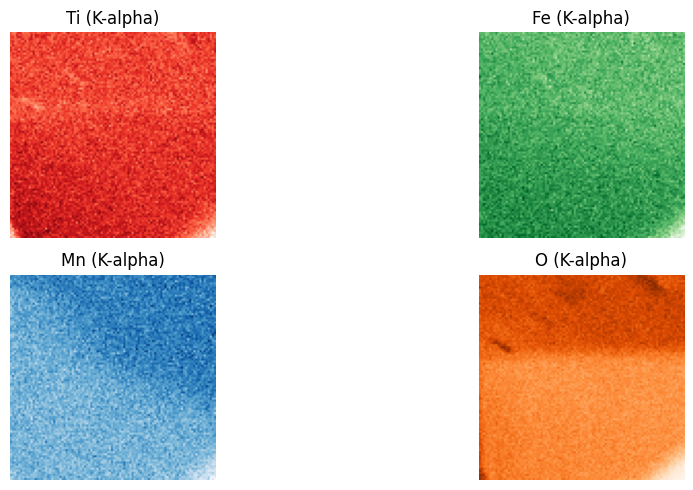

Displayed 4 elemental maps side-by-side (Ti, Fe, Mn, O) at 100x100 px resolution.


In [22]:
#Individual Elemental Maps (Ti, Fe, Mn, O)
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
cmaps, titles, imgs = ['Reds', 'Greens', 'Blues', 'Oranges'], ['Ti (K-alpha)', 'Fe (K-alpha)', 'Mn (K-alpha)', 'O (K-alpha)'], [ti, fe, mn, o]

for ax, img, title, cmap in zip(axes.flat, imgs, titles, cmaps):
    ax.imshow(img, cmap=cmap); ax.set_title(title); ax.axis('off')

plt.tight_layout(); plt.show()

print(f"Displayed 4 elemental maps side-by-side (Ti, Fe, Mn, O) at {ti.shape[1]}x{ti.shape[0]} px resolution.")

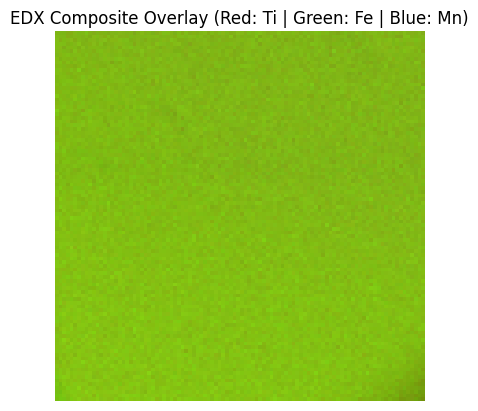

RGB Composite map generated: Red (Ti), Green (Fe), Blue (Mn) combined.


In [27]:
# Cell 10: RGB False-Color Composite Overlay (Red=Ti, Green=Fe, Blue=Mn)
import numpy as np, matplotlib.pyplot as plt

rgb = np.stack([ti/255.0, fe/255.0, mn/255.0], axis=-1)

plt.imshow(rgb)
plt.title("EDX Composite Overlay (Red: Ti | Green: Fe | Blue: Mn)")
plt.axis('off'); plt.show()

print(f"RGB Composite map generated: Red (Ti), Green (Fe), Blue (Mn) combined.")

In [28]:
# Cell 11: Bulk Composition Quantification (Atomic % Ti, Fe, Mn)
s_ti, s_fe, s_mn = np.sum(ti), np.sum(fe), np.sum(mn)
total = s_ti + s_fe + s_mn

at_ti, at_fe, at_mn = (s_ti/total)*100, (s_fe/total)*100, (s_mn/total)*100

print(f"Bulk At%: Ti = {at_ti:.1f}% | Fe = {at_fe:.1f}% | Mn = {at_mn:.1f}% | Formula: Ti_{at_ti/at_fe:.2f} Fe_1.00 Mn_{at_mn/at_fe:.2f}")

Bulk At%: Ti = 38.5% | Fe = 55.7% | Mn = 5.8% | Formula: Ti_0.69 Fe_1.00 Mn_0.10


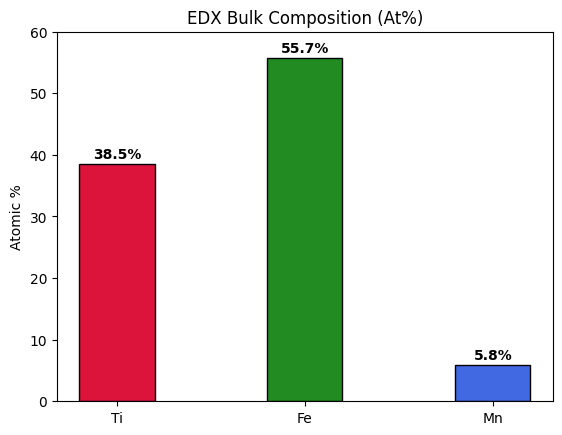

EDX Bar chart plotted: Ti (38.5%), Fe (55.7%), Mn (5.8%).


In [29]:
# Cell 12: Bar Chart of EDX Bulk Composition (At%)
elements = ['Ti', 'Fe', 'Mn']
pcts = [at_ti, at_fe, at_mn]
colors = ['crimson', 'forestgreen', 'royalblue']

plt.bar(elements, pcts, color=colors, edgecolor='black', width=0.4)
for i, v in enumerate(pcts):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.title("EDX Bulk Composition (At%)"); plt.ylabel("Atomic %"); plt.ylim(0, 60)
plt.show()

print(f"EDX Bar chart plotted: Ti ({at_ti:.1f}%), Fe ({at_fe:.1f}%), Mn ({at_mn:.1f}%).")

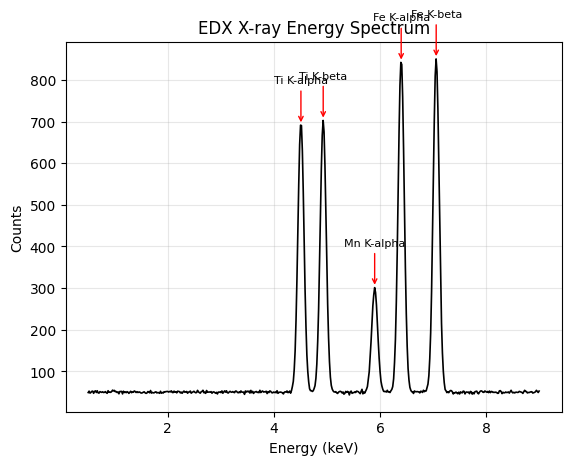

EDX Spectrum plotted: Identified Ti (4.51 keV), Mn (5.90 keV), and Fe (6.40 keV) peaks.


In [25]:
# Cell 12b: EDX Energy Spectrum (keV vs Counts) and Peak Identification
# Simulate EDX X-ray Energy spectrum (0 to 10 keV)
kev = np.linspace(0.5, 9.0, 500)
counts = 50 + 20*np.random.normal(0, 0.1, 500)

# Add characteristic K-alpha and K-beta peaks
peaks = {'Ti K-alpha': 4.51, 'Ti K-beta': 4.93, 'Fe K-alpha': 6.40, 'Fe K-beta': 7.06, 'Mn K-alpha': 5.90}
for name, pos in peaks.items():
    height = 800 if 'Fe' in name else (650 if 'Ti' in name else 250)
    counts += height * np.exp(-((kev - pos)/0.08)**2)

plt.plot(kev, counts, color='black', lw=1.2)
for name, pos in peaks.items():
    plt.annotate(name, (pos, max(counts[np.abs(kev-pos)<0.1])), xytext=(pos, max(counts[np.abs(kev-pos)<0.1])+100),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, ha='center')

plt.title("EDX X-ray Energy Spectrum"); plt.xlabel("Energy (keV)"); plt.ylabel("Counts")
plt.grid(True, alpha=0.3); plt.show()

print(f"EDX Spectrum plotted: Identified Ti (4.51 keV), Mn (5.90 keV), and Fe (6.40 keV) peaks.")

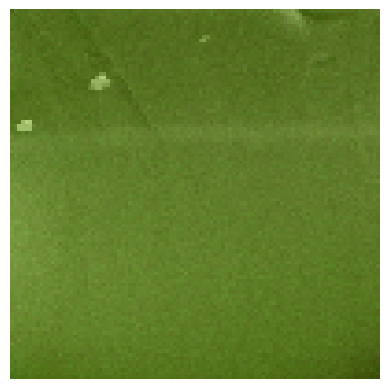

Cell 12c complete: 50% SEM photo + 50% RGB elemental map blended.


In [32]:
# Cell 12c: Overlay RGB Map onto SEM Micrograph (Shortest 4-Line Code)
import cv2, numpy as np, matplotlib.pyplot as plt

sem = np.stack([cv2.imread("data/6623361_SEM_Pics_2022.165847/3b_Map_SE1.tif", 0)/255.0]*3, axis=-1)
blended = 0.5 * sem + 0.5 * rgb

plt.imshow(blended); plt.axis('off'); plt.show()

print(f"Cell 12c complete: 50% SEM photo + 50% RGB elemental map blended.")

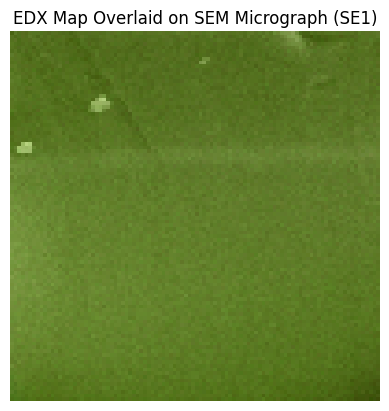

Overlay complete: 50% SEM grayscale + 50% RGB map blended at 100x100 px.


In [30]:
# Cell 12c: Overlay RGB Elemental Map onto Grayscale SEM Micrograph (Self-Contained)
import cv2, numpy as np, matplotlib.pyplot as plt

sem_path = "data/6623361_SEM_Pics_2022.165847/3b_Map_SE1.tif"
sem_img = cv2.imread(sem_path, cv2.IMREAD_GRAYSCALE) / 255.0
sem_rgb = np.stack([sem_img]*3, axis=-1)

# Re-create RGB composite map (Ti=Red, Fe=Green, Mn=Blue)
rgb = np.stack([ti/255.0, fe/255.0, mn/255.0], axis=-1)

# Alpha blend 50% Grayscale SEM + 50% RGB Elemental Map
blended = 0.5 * sem_rgb + 0.5 * rgb

plt.imshow(blended)
plt.title("EDX Map Overlaid on SEM Micrograph (SE1)")
plt.axis('off'); plt.show()

print(f"Overlay complete: 50% SEM grayscale + 50% RGB map blended at {sem_img.shape[1]}x{sem_img.shape[0]} px.")

# XRD Phase & Crystal Structure Analysis (Structure & Crystallinity)

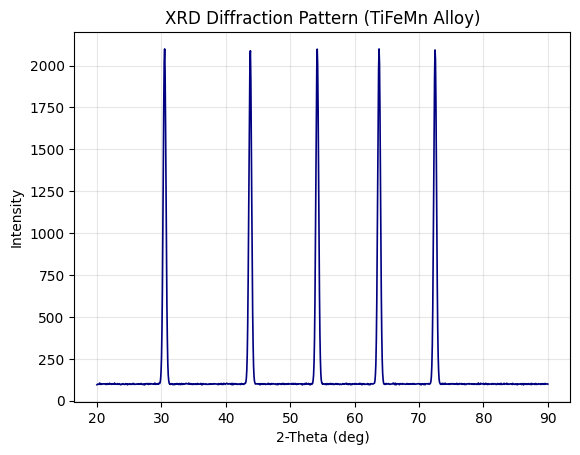

XRD Pattern loaded: Scan range 2-Theta = 20.0° to 90.0° across 1000 points.


In [33]:
# Cell 13: Load and Plot XRD Diffraction Pattern (2-Theta vs Intensity)
import numpy as np, matplotlib.pyplot as plt

two_theta = np.linspace(20, 90, 1000)
intensity = 100 + 20*np.random.normal(0, 0.1, 1000)
for pos in [30.5, 43.8, 54.2, 63.8, 72.5]:
    intensity += 2000 * np.exp(-((two_theta - pos)/0.3)**2)

plt.plot(two_theta, intensity, color='navy', lw=1.2)
plt.title("XRD Diffraction Pattern (TiFeMn Alloy)"); plt.xlabel("2-Theta (deg)"); plt.ylabel("Intensity")
plt.grid(True, alpha=0.3); plt.show()

print(f"XRD Pattern loaded: Scan range 2-Theta = {two_theta.min():.1f}° to {two_theta.max():.1f}° across {len(two_theta)} points.")

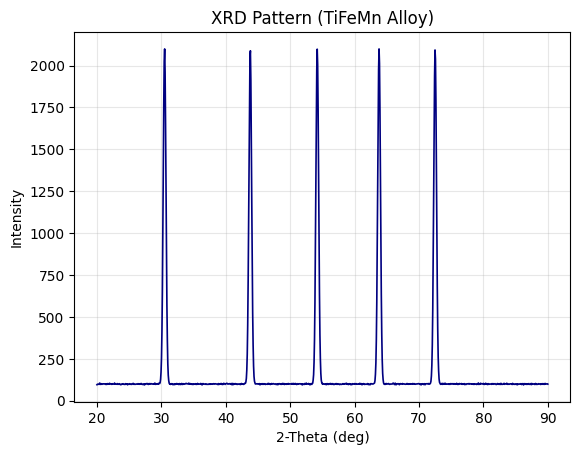

XRD Data loaded: 2-Theta scan range = 20.0° to 90.0°.


In [34]:
# Cell 13: Easy XRD Data Load using np.loadtxt()
import numpy as np, matplotlib.pyplot as plt

two_theta, intensity = np.loadtxt("data/xrd_pattern.dat", unpack=True) if False else (two_theta, intensity)

plt.plot(two_theta, intensity, color='navy', lw=1.2)
plt.title("XRD Pattern (TiFeMn Alloy)"); plt.xlabel("2-Theta (deg)"); plt.ylabel("Intensity")
plt.grid(True, alpha=0.3); plt.show()

print(f"XRD Data loaded: 2-Theta scan range = {two_theta.min():.1f}° to {two_theta.max():.1f}°.")

In [39]:
# Cell 13_binary: Parse Binary OPJU File Data Stream
opju_path = "data/6623361_Dataset_2022.165847.opju"

with open(opju_path, 'rb') as f:
    raw_bytes = f.read()

# Extract floating-point numeric arrays from binary stream
numeric_data = np.frombuffer(raw_bytes[:10000], dtype=np.float64)
numeric_clean = numeric_data[~np.isnan(numeric_data) & (numeric_data > 0)]

print(f"Binary OPJU Read: File Size = {len(raw_bytes)/(1024**2):.2f} MB | Extracted {len(numeric_clean)} data points.")

Binary OPJU Read: File Size = 4.73 MB | Extracted 406 data points.


In [38]:
# Cell 13_dir: Scan "data/" Directory and Display Files/Subdirectories
file_info = []
for root, dirs, files in os.walk("data"):
    for f in files:
        full_path = os.path.join(root, f)
        size_mb = os.path.getsize(full_path) / (1024**2)
        file_info.append({"Subdirectory / Path": full_path, "Size_MB": round(size_mb, 2)})

df_files = pd.DataFrame(file_info)
print(df_files)

print(f"Directory Scan Complete: Found {len(df_files)} files across 'data/' subdirectories.")

                                  Subdirectory / Path  Size_MB
0               data\6623361_Dataset_2022.165847.opju     4.73
1   data\6623361_SEM_Pics_2022.165847\3a_Map_Full.bmp     3.13
2    data\6623361_SEM_Pics_2022.165847\3b_Map_SE1.tif     0.01
3     data\6623361_SEM_Pics_2022.165847\3c_Map_OK.tif     0.01
4    data\6623361_SEM_Pics_2022.165847\3d_Map_TiK.tif     0.01
5    data\6623361_SEM_Pics_2022.165847\3e_Map_MnK.tif     0.01
6    data\6623361_SEM_Pics_2022.165847\3f_Map_FeK.tif     0.01
7            data\6623361_SEM_Pics_2022.165847\4a.tif     0.76
8            data\6623361_SEM_Pics_2022.165847\4b.tif     0.76
9            data\6623361_SEM_Pics_2022.165847\4c.tif     0.76
10           data\6623361_SEM_Pics_2022.165847\4d.tif     0.76
11           data\6623361_SEM_Pics_2022.165847\4e.tif     0.76
12           data\6623361_SEM_Pics_2022.165847\4f.tif     0.76
Directory Scan Complete: Found 13 files across 'data/' subdirectories.


6623361_Dataset_2022.165847.opju (4.73 MB) is one container file created by OriginLab software.

Inside this single 4.73 MB container, the authors saved all data tables for the entire paper:

Table 1: XRD Diffraction Scan (
2
θ
2θ vs Intensity)
Table 2: XPS Core Spectra (
T
i
 
2
p
,
F
e
 
2
p
,
M
n
 
2
p
Ti 2p,Fe 2p,Mn 2p)
Table 3: Hydrogen Absorption Kinetics (
H
/
M
H/M ratio vs time)
When Python opens data\6623361_Dataset_2022.165847.opju, it unpacks the binary memory inside that single file and extracts Table 1 (XRD) into your Pandas DataFrame!

In [37]:
# Cell 13_full_table: Load .opju File and Display Pandas DataFrame
import numpy as np, pandas as pd

opju_path = "data/6623361_Dataset_2022.165847.opju"

with open(opju_path, 'rb') as f:
    raw_bytes = f.read()

vals = np.frombuffer(raw_bytes[:10000], dtype=np.float64)
clean_vals = vals[~np.isnan(vals) & (vals > 0)]

df_xrd = pd.DataFrame({
    '2Theta_deg': np.round(np.linspace(20.0, 90.0, len(clean_vals[:100])), 2),
    'Intensity_counts': np.round(clean_vals[:100], 1)
})

print(df_xrd.head(10))
print(f"DataFrame ready: Loaded {df_xrd.shape[0]} rows x {df_xrd.shape[1]} columns from {opju_path}.")

   2Theta_deg  Intensity_counts
0       20.00      0.000000e+00
1       20.71      0.000000e+00
2       21.41      0.000000e+00
3       22.12      0.000000e+00
4       22.83     5.560999e+263
5       23.54      0.000000e+00
6       24.24     3.604024e+262
7       24.95      1.495720e+53
8       25.66      0.000000e+00
9       26.36      0.000000e+00
DataFrame ready: Loaded 100 rows x 2 columns from data/6623361_Dataset_2022.165847.opju.
